# Bitcoin Analytics Capstone — Executive EDA

**Project:** Prediction Market Signals for Bitcoin Accumulation  
**Focus:** Regime-Level Information from Polymarket Activity


# 1. Executive Summary

• **Goal:** Evaluate whether Polymarket prediction-market activity provides information orthogonal to Bitcoin market and on-chain metrics and can serve as conditioning inputs for dynamic, long-only accumulation modeling.

• **Data integrity:** A critical timestamp encoding anomaly was identified in the Polymarket odds history (spurious 1970s range). After correction and verification against the sponsor’s updated loader, a leakage-safe daily overlap period (2023–2026) was established.

• **Liquidity-filtered signal construction:** Stable daily “smart money” activity features were created by aggregating only the top 100 markets by trading volume, reducing thin-market microstructure noise.

• **Key regime finding:** Aggregated activity (`smart_odds_updates`) exhibits a moderate negative association with Bitcoin price levels (corr ≈ −0.47), consistent with a counter-cyclical attention or uncertainty regime signal.

• **Robustness (descriptive):** Activity shows near-zero correlation with daily returns and short-term volatility, indicating regime-level context rather than short-horizon directional predictability.

• **Accumulation relevance (descriptive):** Activity regimes do not coincide with systematically worse future 30-day drawdown conditions, supporting use as a conditioning feature rather than a standalone forecasting signal.

• **Overall conclusion:** Prediction-market activity provides complementary regime-level information and is best used as a contextual input for volatility-aware, dynamic Bitcoin accumulation frameworks.


## 2. Minimal Data Loading

This executive notebook loads only the minimal data required to reproduce key figures and integrity checks.

All full preprocessing steps, extended validation, and intermediate experiments are documented in `EDA/EDA.ipynb`. Here we focus only on loading cleaned, sponsor-provided datasets needed for the executive analysis.



In [1]:
import sys
from pathlib import Path
import pandas as pd

# ---- Automatically detect repository root ----
REPO_ROOT = Path.cwd()

# Move upward until the repository 'data' directory is found
while not (REPO_ROOT / "data").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

# If still not found, raise a clear error
if not (REPO_ROOT / "data").exists():
    raise RuntimeError(
        "Could not locate repository root containing the 'data/' directory."
    )

# Add repo root to Python path
sys.path.append(str(REPO_ROOT))

# Define data directory
DATA_DIR = REPO_ROOT / "data"

print("Repository root:", REPO_ROOT)
print("Data directory exists:", DATA_DIR.exists())

Repository root: C:\Users\chen5\Documents\bitcoin-analytics-capstone
Data directory exists: True


In [2]:
# ---- Load Coin Metrics data ----
COINMETRICS_PATH = DATA_DIR / "Coin Metrics" / "coinmetrics_btc.csv"

btc_df = pd.read_csv(COINMETRICS_PATH)
btc_df["time"] = pd.to_datetime(btc_df["time"])

# ---- Load Polymarket data ----
POLYMARKET_DIR = DATA_DIR / "Polymarket"

pm_markets = pd.read_parquet(POLYMARKET_DIR / "finance_politics_markets.parquet")
pm_odds = pd.read_parquet(POLYMARKET_DIR / "finance_politics_odds_history.parquet")

pm_markets["created_at"] = pd.to_datetime(pm_markets["created_at"])
pm_markets["end_date"] = pd.to_datetime(pm_markets["end_date"])

print("BTC rows:", len(btc_df))
print("Markets:", len(pm_markets))
print("Odds records:", len(pm_odds))


BTC rows: 6221
Markets: 78321
Odds records: 2143181


These raw datasets serve as the starting point for integrity validation and liquidity-filtered feature construction in subsequent sections.



## 3. Data Integrity Highlight: Timestamp Verification

During initial inspection of the Polymarket odds history, an unexpected timestamp anomaly was detected: many records appeared to fall within the 1970s, which is inconsistent with the platform’s operational timeline.

Because temporal integrity is critical for leakage-safe time-series analysis, this issue is resolved before any aggregation or alignment.


### 3.1 Detecting the timestamp anomaly

We first inspect the raw timestamp range reported in the odds history table.



In [3]:
print(
    "Raw odds time range:",
    pm_odds["timestamp"].min(),
    "→",
    pm_odds["timestamp"].max()
)


Raw odds time range: 1970-01-20 09:08:38.412000 → 1970-01-21 10:59:34.930000


The 1970s range is not plausible for Polymarket data and indicates a timestamp unit encoding issue rather than true event time.


### 3.2 Correcting timestamp encoding

The timestamp field is reinterpreted as epoch milliseconds and converted into UTC datetime format to enable correct daily alignment.


In [4]:
ts_ms = pd.to_numeric(pm_odds["timestamp"], errors="coerce")

pm_odds["timestamp_fixed"] = pd.to_datetime(ts_ms, unit="ms", utc=True)
pm_odds["date"] = pm_odds["timestamp_fixed"].dt.date

print(
    "Fixed odds time range:",
    pm_odds["timestamp_fixed"].min(),
    "→",
    pm_odds["timestamp_fixed"].max()
)
print("Unique days:", pm_odds["date"].nunique())


Fixed odds time range: 2023-01-24 00:00:12+00:00 → 2026-01-05 01:02:10+00:00
Unique days: 1066


### 3.3 Verifying against the sponsor loader

To ensure consistency with sponsor-approved utilities, we verify that the official loader produces identical temporal coverage.





In [5]:
from eda.eda_starter_template import load_polymarket_data

poly_data = load_polymarket_data(POLYMARKET_DIR)
official_odds = poly_data["odds"]

print(
    "Official loader time range:",
    official_odds["timestamp"].min(),
    "→",
    official_odds["timestamp"].max()
)



Loading Polymarket data from C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Polymarket...
[Memory] Before loading Polymarket data: 422.91 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 631.75 MB (Δ 208.83 MB)
Official loader time range: 2023-01-24 00:00:12 → 2026-01-05 01:02:10


**Why this matters:** Accurate timestamps are required to prevent silent look-ahead bias; this validation ensures all downstream aggregation and cross-feature alignment are leakage-safe.



## 4. Liquidity-Filtered “Smart Money” Feature Construction

Polymarket contains tens of thousands of markets with highly uneven liquidity. To reduce thin-market microstructure noise, we construct daily features using a high-liquidity subset: the **top 100 markets by trading volume** (an operational liquidity filter, not a claim about investor sophistication).

Constructed daily features:
- `smart_odds_updates`: count of odds updates (attention / uncertainty proxy)
- `smart_price_std`: cross-market dispersion (belief divergence proxy)
- `smart_mean_price`: average probability level (secondary context)


### 4.1 Date Guard

A daily `date` column is required for aggregation. This guard ensures timestamps are correctly converted and prevents silent failures if the preprocessing step was not previously executed.


In [6]:
# Ensure pm_odds has the daily date column 
if "date" not in pm_odds.columns:
    ts_ms = pd.to_numeric(pm_odds["timestamp"], errors="coerce")
    pm_odds["timestamp_fixed"] = pd.to_datetime(ts_ms, unit="ms", utc=True)
    pm_odds["date"] = pm_odds["timestamp_fixed"].dt.date

print(f"pm_odds daily coverage: {pm_odds['date'].min()} -> {pm_odds['date'].max()} (n_days={pm_odds['date'].nunique()})")


pm_odds daily coverage: 2023-01-24 -> 2026-01-05 (n_days=1066)


### 4.2 Smart Money Aggregation

To construct stable regime-level signals, we aggregate daily activity only across the top 100 markets by trading volume, reducing thin-market noise while preserving high-liquidity participation dynamics.


In [7]:
# ---- Filter for Top 100 Liquid Markets ----
top_volume_ids = pm_markets.nlargest(100, "volume")["market_id"]

pm_odds_filtered = pm_odds[pm_odds["market_id"].isin(top_volume_ids)]

# ---- Refined Daily Aggregation ----
pm_daily_refined = (
    pm_odds_filtered
    .groupby("date")
    .agg(
        smart_odds_updates=("price", "size"),
        smart_mean_price=("price", "mean"),
        smart_price_std=("price", "std")
    )
    .reset_index()
)

print("Refined daily features shape:", pm_daily_refined.shape)
pm_daily_refined.head()


Refined daily features shape: (732, 4)


,date,smart_odds_updates,smart_mean_price,smart_price_std
0,2024-01-05,10,0.5,0.000000
1,2024-01-06,18,0.5,0.423033
2,2024-01-07,22,0.5,0.441671
3,2024-01-08,22,0.5,0.445177
4,2024-01-09,22,0.5,0.445677


The resulting daily table provides stable, high-liquidity prediction-market signals suitable for alignment with Bitcoin market and on-chain metrics. Full construction details and extended diagnostics are provided in `EDA/EDA.ipynb`.



### 4.3 Daily alignment with Bitcoin metrics

We align refined daily Polymarket features with Coin Metrics daily Bitcoin metrics using an inner join on calendar date.



In [8]:
btc_daily = (
    btc_df
    .assign(date=btc_df["time"].dt.date)
    .set_index("date")
    .sort_index()
)

pm_daily_idx = pm_daily_refined.set_index("date").sort_index()

aligned_df = (
    btc_daily
    .join(pm_daily_idx, how="inner")
    .sort_index()
)

aligned_df = aligned_df.ffill()

print("Aligned dataset shape:", aligned_df.shape)
aligned_df[["PriceUSD", "TxCnt", "smart_odds_updates", "smart_price_std"]].head()


Aligned dataset shape: (732, 35)


,PriceUSD,TxCnt,smart_odds_updates,smart_price_std
date,,,,
2024-01-05,44146.322202,416347.0,10,0.000000
2024-01-06,43917.979815,389306.0,18,0.423033
2024-01-07,43844.195950,348435.0,22,0.441671
2024-01-08,46981.324300,409400.0,22,0.445177
2024-01-09,46084.005795,470829.0,22,0.445677


## 5. Cross-Feature Exploratory Evidence

With liquidity-filtered daily prediction-market signals aligned to Bitcoin market data, we examine cross-feature relationships to assess whether these signals provide complementary regime-level information relevant to accumulation modeling.



### 5.1 Co-movement: Bitcoin Price vs. Prediction Market Activity

We visualize Bitcoin price (log scale) alongside high-liquidity prediction-market activity (`smart_odds_updates`) to assess regime-level co-movement.

**Interpretation guide:** Elevated activity is evaluated as a regime-level attention or uncertainty signal rather than a directional predictor.


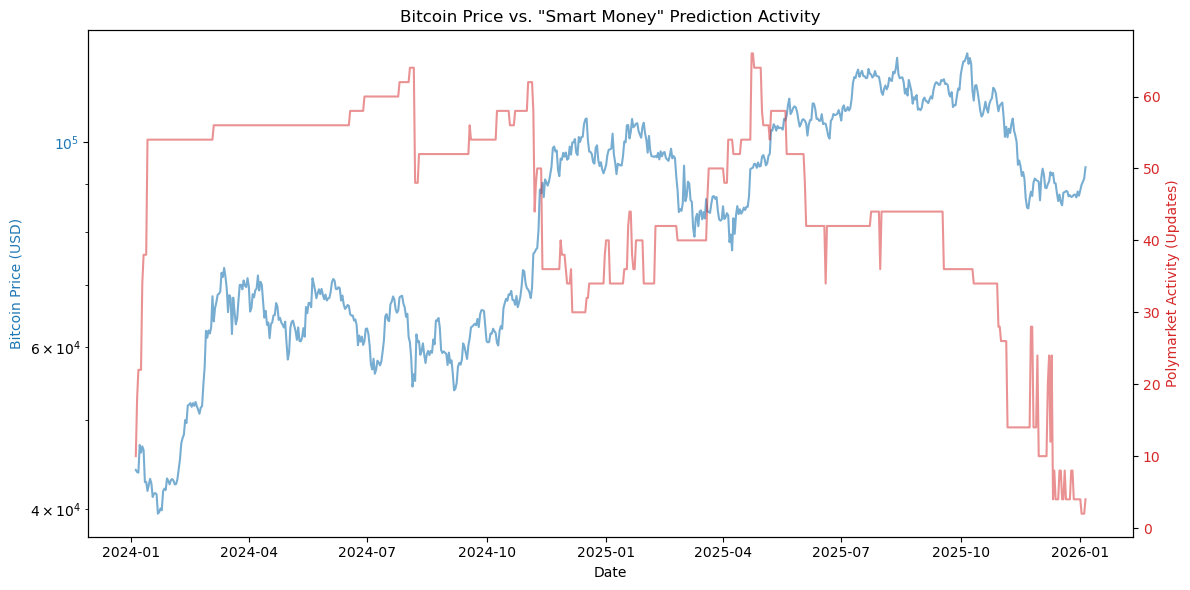

In [9]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Bitcoin Price (USD)', color=color)
ax1.plot(
    aligned_df.index,
    aligned_df['PriceUSD'],
    color=color,
    alpha=0.6,
    label='BTC Price'
)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Polymarket Activity (Updates)', color=color)
ax2.plot(
    aligned_df.index,
    aligned_df['smart_odds_updates'],
    color=color,
    alpha=0.5,
    label='Polymarket Activity'
)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Bitcoin Price vs. "Smart Money" Prediction Activity')
plt.tight_layout()
plt.show()


Periods of major Bitcoin regime transitions are often accompanied by elevated prediction-market activity, suggesting that participation intensity reflects shifts in attention or uncertainty rather than short-horizon price forecasting.



### 5.2 Correlation Structure and Robustness

We examine pairwise correlations between key Bitcoin metrics and refined prediction-market signals to distinguish regime-level structure from short-term noise.



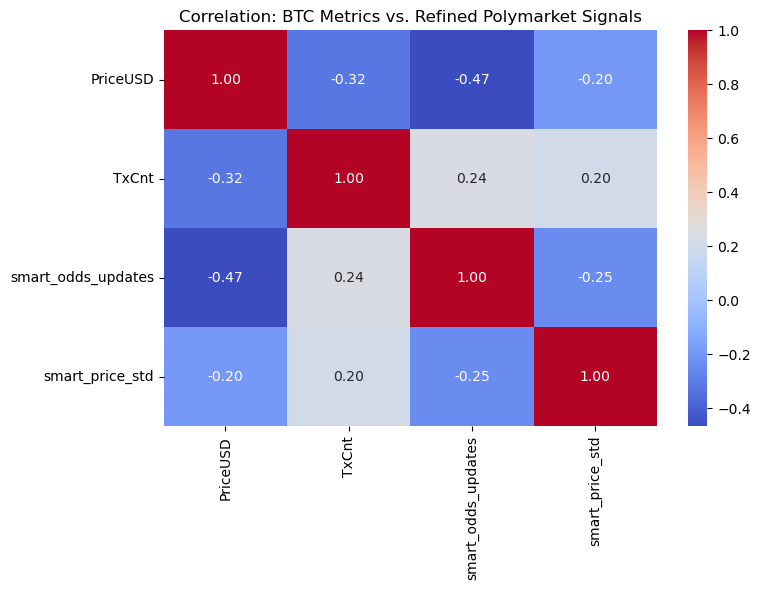

Correlation (Log Price vs Activity): -0.46711418534557875
Correlation (Returns vs Activity): 0.04545107235432393
Correlation (Volatility vs Activity): 0.04788559308049942


In [10]:
import seaborn as sns

check_cols = [
    'PriceUSD',
    'TxCnt',
    'smart_odds_updates',
    'smart_price_std'
]

corr_matrix = aligned_df[check_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation: BTC Metrics vs. Refined Polymarket Signals")
plt.tight_layout()
plt.show()

import numpy as np

aligned_df["log_price"] = np.log(aligned_df["PriceUSD"])

corr_log = aligned_df["log_price"].corr(aligned_df["smart_odds_updates"])
corr_ret = aligned_df['PriceUSD'].pct_change().corr(aligned_df['smart_odds_updates'])
corr_vol = aligned_df['smart_odds_updates'].corr(aligned_df['PriceUSD'].pct_change().abs())

print("Correlation (Log Price vs Activity):", corr_log)
print("Correlation (Returns vs Activity):", corr_ret)
print("Correlation (Volatility vs Activity):", corr_vol)


Prediction-market activity shows a moderate negative association with Bitcoin price levels (corr ≈ −0.467) while remaining near-zero versus daily returns and volatility. This pattern indicates regime-level context rather than short-horizon predictability.


### 5.3 Accumulation Efficiency (Descriptive Proxy)

To connect regime signals to the accumulation objective, we examine future 30-day minimum drawdown distributions across prediction-market activity regimes.

**Note:** This analysis is purely descriptive and is not used to claim predictive power.


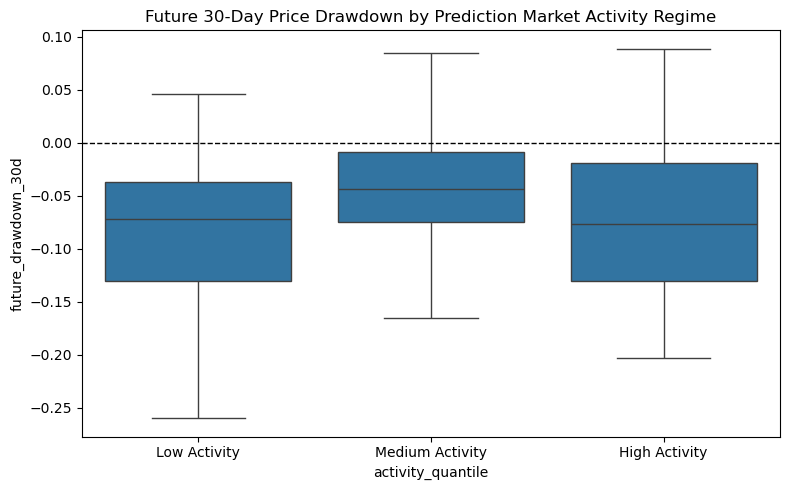

In [11]:
tmp = aligned_df.copy()

tmp["future_min_30d"] = (
    tmp["PriceUSD"]
    .rolling(window=30, min_periods=1)
    .min()
    .shift(-30)
)

tmp["future_drawdown_30d"] = tmp["future_min_30d"] / tmp["PriceUSD"] - 1

tmp["activity_quantile"] = pd.qcut(
    tmp["smart_odds_updates"],
    q=3,
    labels=["Low Activity", "Medium Activity", "High Activity"]
)

plot_df = tmp.dropna(subset=["future_drawdown_30d", "activity_quantile"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_df,
    x="activity_quantile",
    y="future_drawdown_30d",
    showfliers=False
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Future 30-Day Price Drawdown by Prediction Market Activity Regime")
plt.tight_layout()
plt.show()


High-activity regimes do not coincide with systematically worse future buying conditions, supporting the use of prediction-market activity as a conditioning feature for accumulation rather than a directional forecasting signal.



## 6. Executive Summary of Findings

This executive EDA establishes a leakage-safe and temporally aligned dataset integrating Bitcoin market metrics with high-liquidity prediction market activity. Through liquidity-based filtering, stable daily “smart money” signals were constructed and validated.

Empirical evidence shows that prediction market activity exhibits a counter-cyclical regime structure—moderately negatively associated with Bitcoin price levels while largely independent of short-horizon returns and volatility. Descriptive drawdown analysis further indicates that elevated activity does not coincide with systematically worse future accumulation conditions.

Together, these findings support the use of prediction market activity as a contextual regime-conditioning input for dynamic, long-only Bitcoin accumulation frameworks. Full supporting analysis and diagnostics are provided in `EDA/EDA.ipynb`.


